In [1]:
#python graded assignment : Tasks
#1. Data Ingestion & Quality Profiling
#Load & Inspect
import pandas as pd
#Read car_prices.csv into a pandas DataFrame.
df=pd.read_csv('/content/car_prices.csv')
#Display the first 5 rows.
df.head(5)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [2]:
#Display data types ,Display record count and column count
df.info()
#Record count: 558837
#column: 16

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [3]:
#1.2. Understanding the Data Structure
#Check the shape of the dataset
df.shape
#Rows: 558837
#Column: 16

(558837, 16)

In [4]:
#1.2. Understanding the Data Structure
#Display column names and data types.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [5]:
#1.3 Missing & Anomaly Detection
#● Quantify nulls per column
null_cnt=df.isnull().sum()
null_cnt.sort_values(ascending=False)


,0
transmission,65352
body,13195
condition,11820
trim,10651
model,10399
make,10301
color,749
interior,749
odometer,94
mmr,38


In [6]:
#Checking percentage of null values.
null_percentage=(null_cnt/len(df))*100
null_percentage.sort_values(ascending=False)

,0
transmission,11.694287
body,2.361154
condition,2.115107
trim,1.905922
model,1.860829
make,1.843292
color,0.134028
interior,0.134028
odometer,0.016821
mmr,0.006800


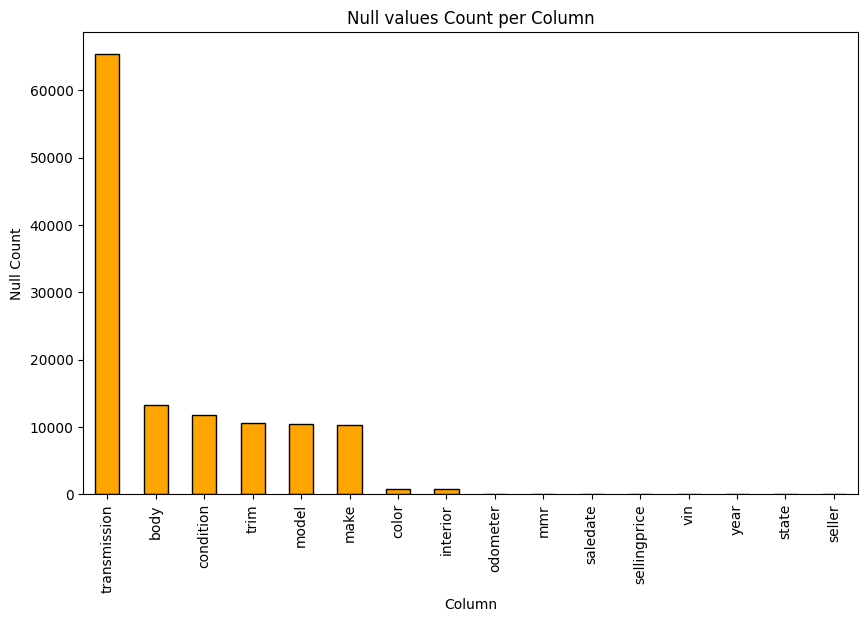

In [7]:
#visualize with a bar chart or heatmap.
import matplotlib.pyplot as plt
null_cnt_sort=df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
null_cnt_sort.plot(kind='bar',color='orange', edgecolor='black')
plt.title('Null values Count per Column')
plt.xlabel('Column')
plt.ylabel('Null Count')
plt.show()

In [8]:
#1.3 Missing & Anomaly Detection
#● Quantify nulls per column
import pandas as pd
#if <5% null then delete strategy
#first:Calculate the percentage of nulls per column
null_perc=df.isnull().mean()*100
#finding specific column(>0-<5%) & storing into the list
col = null_perc[(null_perc > 0) & (null_perc < 5)].index.tolist()
#drop rows only above specific columns stores in list,and getCleaned dataframe: df_cleaned
df_cleaned=df.dropna(subset=col).copy()

In [9]:
print(df_cleaned.shape)

(533648, 16)


In [10]:
#Median for Numeric 5-30%
#finding specific column(>5-<30%) & storing into the list
null_perc=df.isnull().mean()*100
mid_null_cols = null_perc[(null_perc >= 5) & (null_perc <= 30)].index.tolist()

In [11]:
print(mid_null_cols)
print(df_cleaned.shape)

['transmission']
(533648, 16)


In [12]:
#Categorical column
#Mode
modevalue=df_cleaned['transmission'].mode()[0]
df_cleaned.loc[:, 'transmission'] = df_cleaned['transmission'].fillna(modevalue)

In [13]:
#body
modevalue=df_cleaned['body'].mode()[0]
df_cleaned.loc[:, 'body'] = df_cleaned['body'].fillna(modevalue)

In [14]:
#codition
modevalue=df_cleaned['condition'].mode()[0]
df_cleaned.loc[:, 'condition'] = df_cleaned['condition'].fillna(modevalue)

In [15]:
print(df_cleaned.shape)

(533648, 16)


In [16]:
# Count total number of duplicate rows
duplicate_count = df_cleaned.duplicated().sum()
print("Total number of duplicate rows:", duplicate_count)
# No duplicate found

Total number of duplicate rows: 0


In [17]:
#2. Data frames Queries:
#2.1 Calculate the average, minimum, and maximum car price?
average_price=df_cleaned['sellingprice'].mean()
max_price=df_cleaned['sellingprice'].max()
min_price=df_cleaned['sellingprice'].min()
print(f"Average Price: {average_price} "\
      f"Maximum Price: {max_price} "\
      f"Minimum Price: {min_price}")


Average Price: 13860.066504512337 Maximum Price: 230000.0 Minimum Price: 1.0


In [18]:
#2.2 List all unique colors of cars?
unique_colors=df_cleaned['color'].unique()
print(unique_colors)

['white' 'gray' 'black' 'red' 'silver' 'brown' 'beige' 'blue' 'purple'
 'burgundy' '—' 'gold' 'yellow' 'green' 'charcoal' 'orange' 'off-white'
 'turquoise' 'pink' 'lime']


In [19]:
#Find the number of unique car brands and car models?
unique_car_brands=df_cleaned['make'].nunique()
unique_car_models=df_cleaned['model'].nunique()
print(f"brand-Models:{unique_car_brands},{unique_car_models}")

brand-Models:53,772


In [20]:
#Find all car information having selling prices greater than $165000
car_info=df_cleaned[df_cleaned['sellingprice']>165000]
car_info

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


In [21]:
#Find the top 5 most frequently sold car models?
top_5_models=df_cleaned['model'].value_counts().head(5)
print(top_5_models)

model
Altima    19159
F-150     14164
Fusion    12835
Camry     12326
Escape    11714
Name: count, dtype: int64


In [22]:
#What is the average selling price of cars by brand (make)?
average_price_by_brand=df_cleaned.groupby('make')['sellingprice'].mean()
print(average_price_by_brand)

make
Acura             14227.218445
Aston Martin      54812.000000
Audi              20173.588287
BMW               21380.865343
Bentley           74349.130435
Buick             10926.795860
Cadillac          15474.520138
Chevrolet         12096.690991
Chrysler          11311.104174
Daewoo              450.000000
Dodge             11306.036346
FIAT              10394.255543
Ferrari          127210.526316
Fisker            46461.111111
Ford              14662.538816
GMC               17140.483668
Geo                 528.947368
HUMMER            15364.615776
Honda             11104.036704
Hyundai           11104.892450
Infiniti          20518.970200
Isuzu              1723.276596
Jaguar            20245.588962
Jeep              15174.187504
Kia               11876.584565
Lamborghini      112625.000000
Land Rover        33302.125293
Lexus             20430.600257
Lincoln           17032.951346
Lotus             40800.000000
MINI              12393.053363
Maserati          45632.442748
Maz

In [23]:
#What is the minimum selling price of cars for each interior?
min_price_by_interior=df_cleaned.groupby('interior')['sellingprice'].min()
print(min_price_by_interior)

interior
beige         100.0
black           1.0
blue          150.0
brown         200.0
burgundy      175.0
gold          250.0
gray            1.0
green         100.0
off-white    3200.0
orange       1200.0
purple        200.0
red           200.0
silver        150.0
tan           100.0
white         350.0
yellow       3100.0
—             150.0
Name: sellingprice, dtype: float64


In [24]:
#2.8 Find highest odometer reading per year from highest to lowest order?
highest_odometer_per_year=df_cleaned.groupby('year')['odometer'].max().sort_values(ascending=False)
print(highest_odometer_per_year)

year
1998    999999.0
1993    999999.0
1999    999999.0
1996    999999.0
1997    999999.0
2006    999999.0
2004    999999.0
2003    999999.0
2002    999999.0
2001    999999.0
2012    999999.0
2009    999999.0
2010    999999.0
2011    999999.0
2014    999999.0
2005    999999.0
2007    999999.0
2008    999999.0
2013    999999.0
2000    462579.0
1992    379307.0
1994    356402.0
1995    340175.0
1990    265498.0
1991    264816.0
2015    100454.0
Name: odometer, dtype: float64


In [25]:
#2.9 Create a new column for car age (assuming the current year is 2025)
current_year=2025
df_cleaned['car_age']=(current_year) - df_cleaned['year']
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 533648 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          533648 non-null  int64  
 1   make          533648 non-null  object 
 2   model         533648 non-null  object 
 3   trim          533648 non-null  object 
 4   body          533648 non-null  object 
 5   transmission  533648 non-null  object 
 6   vin           533648 non-null  object 
 7   state         533648 non-null  object 
 8   condition     533648 non-null  float64
 9   odometer      533648 non-null  float64
 10  color         533648 non-null  object 
 11  interior      533648 non-null  object 
 12  seller        533648 non-null  object 
 13  mmr           533648 non-null  float64
 14  sellingprice  533648 non-null  float64
 15  saledate      533648 non-null  object 
 16  car_age       533648 non-null  int64  
dtypes: float64(4), int64(2), object(11)
memory usage: 73.

In [26]:
#2.10 Find the number of cars having a condition greater than or equal to 48 and odometer greater than 90000?
df_cleaned.loc[:, 'condition'] = df_cleaned['condition'].fillna(df_cleaned['condition'].median())
condition_count = ((df_cleaned['condition'] >= 48) & (df_cleaned['odometer'] > 90000)).sum()
print(f"Number of cars: {condition_count}")

Number of cars: 719


In [27]:
display(df_cleaned.describe())

,year,condition,odometer,mmr,sellingprice,car_age
count,533648.000000,533648.000000,533648.000000,533648.000000,533648.000000,533648.000000
mean,2010.231083,30.800012,66254.095940,14013.458825,13860.066505,14.768917
std,3.828460,13.368147,52093.614999,9599.502736,9673.553875,3.828460
min,1990.000000,1.000000,1.000000,25.000000,1.000000,10.000000
25%,2008.000000,24.000000,27746.000000,7575.000000,7300.000000,12.000000
50%,2012.000000,35.000000,50146.000000,12500.000000,12400.000000,13.000000
75%,2013.000000,42.000000,95814.000000,18500.000000,18400.000000,17.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000,35.000000


In [28]:
#2.11 Which state consistently has higher car prices for newer cars(year>2013)?
state_avg_price = df_cleaned[df_cleaned['year'] > 2013].groupby('state')['sellingprice'].mean()
state_avg_price = state_avg_price.sort_values(ascending=False)
print(state_avg_price)

state
ab    27326.146789
oh    27212.939917
on    23977.821782
nj    23501.718760
qc    22990.883978
ns    22950.000000
pa    22168.570220
tn    21784.084008
mi    21454.057381
ca    20958.160885
co    20598.126464
wa    20586.452211
fl    20263.494595
ne    20052.976816
il    19975.002344
ga    19938.013580
tx    19888.513243
nv    19852.988104
la    19839.300000
mn    19699.154577
ny    19669.461078
mo    19578.771978
va    19192.581888
wi    19143.157368
ut    18895.031056
az    18851.685007
hi    18063.157895
md    17894.541139
ma    17709.558824
nc    17300.605505
sc    17005.181560
or    16535.892116
ms    16167.405063
in    15668.924303
pr    15379.863481
nm    15214.285714
al    14900.000000
ok    10600.000000
Name: sellingprice, dtype: float64


In [29]:
#2.12 For cars with excellent condition (top 20%), which makes have the lowest average price (value for money)?
excellent_condition_cars = df_cleaned[df_cleaned['condition'] == 5]
average_price_by_make = excellent_condition_cars.groupby('make')['sellingprice'].mean()
average_price_by_make = average_price_by_make.sort_values(ascending=False)
print(average_price_by_make)

make
Bentley          94750.000000
Tesla            76637.500000
Land Rover       60899.275362
Porsche          58462.765957
Maserati         58437.500000
Jaguar           55205.611111
Fisker           48400.000000
Mercedes-Benz    45481.315789
BMW              39812.094907
Lexus            36286.538462
Audi             35178.014184
Cadillac         33011.764706
Ram              30516.666667
Infiniti         30093.103448
GMC              29550.562701
Lincoln          29166.568047
Acura            27680.000000
Jeep             26440.175953
Chevrolet        24842.063492
Ford             23942.623918
Toyota           22971.890041
Subaru           22024.080268
Honda            21058.125000
Buick            21008.783505
HUMMER           20620.000000
Hyundai          20504.126214
MINI             20503.888889
Volvo            20500.000000
Dodge            20159.800664
Mazda            19906.880734
Chrysler         19270.039256
Volkswagen       17862.121212
Kia              17701.983664
Nissa

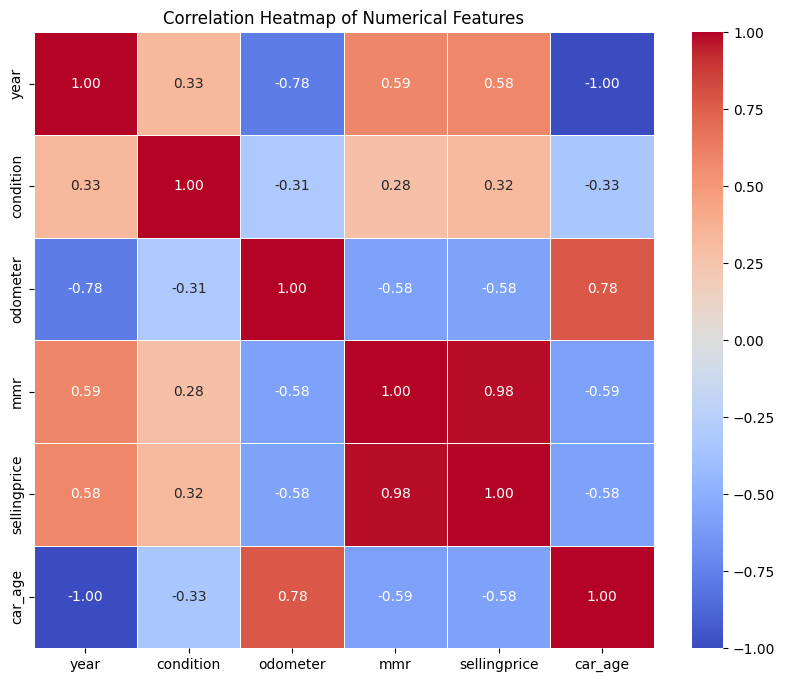

In [30]:
#3.1 Show the correlation of all the features(columns) having numerical values(e.g. selling price, odometer).
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# correlation between numeric columns using pandas
corr_matrix = df_cleaned.corr(numeric_only=True)

# Set the figure size
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

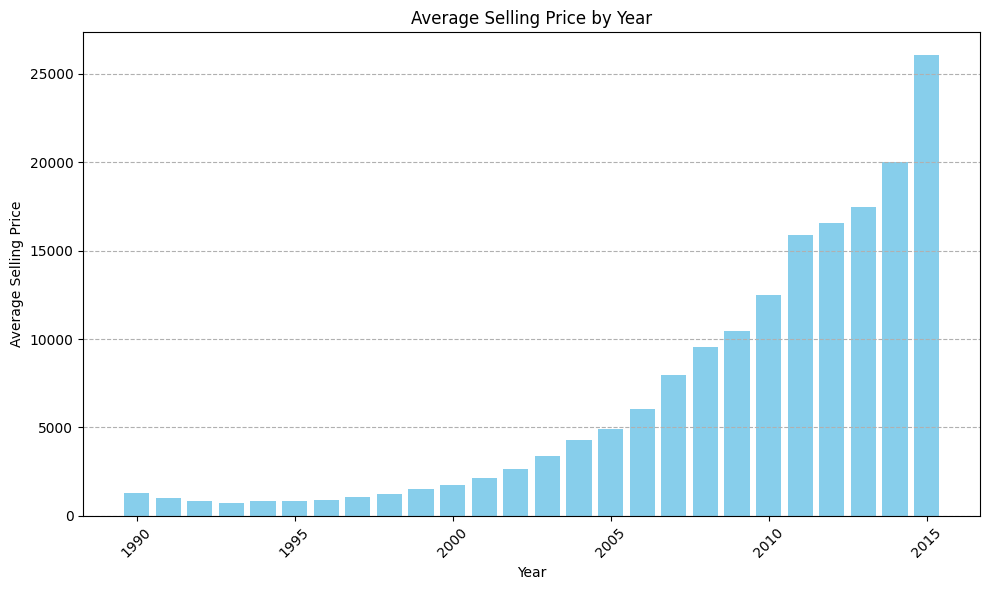

In [31]:
#3.2 Plot a graph to show the average selling price by year and explain the pattern you notice from the graph.
#Which plot will you use bar or scatter
import matplotlib.pyplot as plt

average_price_by_year = df_cleaned.groupby('year')['sellingprice'].mean()

plt.figure(figsize=(10, 6))
plt.bar(average_price_by_year.index, average_price_by_year.values, color='skyblue')
plt.title('Average Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Selling Price')
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#pattern I notice:
#Height of the bars generally increasing (Upward Trend)
#sudden spike observed in the year : 2011 and 2015, means average car price were high due to high demand.
#Year 1990 to 2000 bars are shorter means average car price were low due to less demand from market

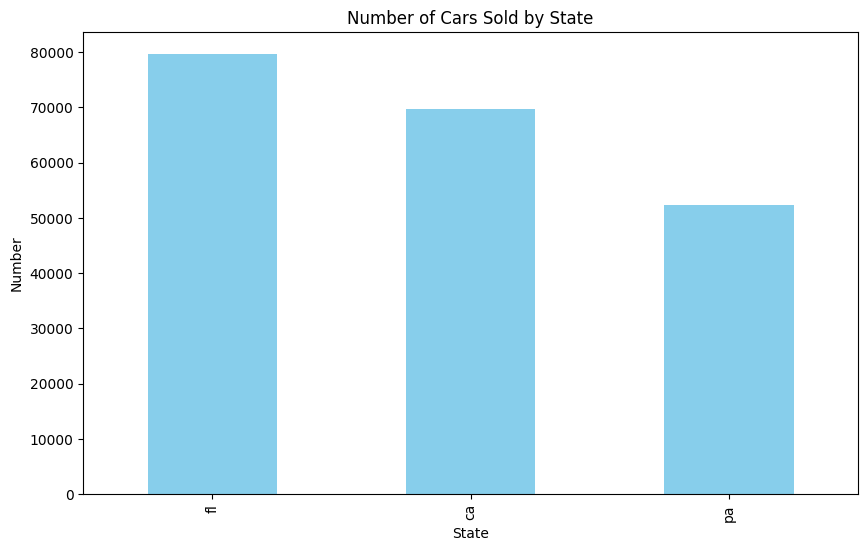

In [32]:
#3.4 Plot a graph to show the number of cars sold in each state. Find the top three highest car selling states
#by having a look at the graph?
import matplotlib.pyplot as plt
import pandas as pd
number_of_cars_sold_by_state=df_cleaned['state'].value_counts()
top_three_states=number_of_cars_sold_by_state.head(3)
plt.figure(figsize=(10,6))
top_three_states.plot(kind='bar',color='skyblue')
plt.title('Number of Cars Sold by State')
plt.xlabel('State')
plt.ylabel('Number')
plt.show()



/tmp/ipykernel_272/2284756235.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_price_by_condition = df_cleaned.groupby(pd.cut(df_cleaned['condition'],\


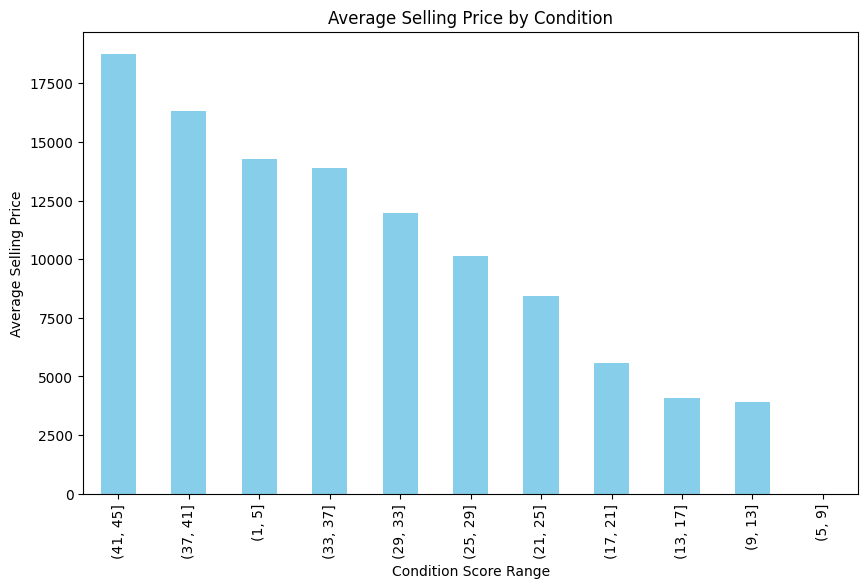

In [33]:
#3.5 Plot a bar graph of average selling price by condition score ranges of size 5.
#Give a summary of the insights.
import matplotlib.pyplot as plt
import pandas as pd
average_price_by_condition = df_cleaned.groupby(pd.cut(df_cleaned['condition'],\
                                                       bins=list(range(1,49,4))))
average_price_by_condition = average_price_by_condition['sellingprice'].mean()
average_price_by_condition=average_price_by_condition.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
average_price_by_condition.plot(kind='bar',color='skyblue')
plt.title('Average Selling Price by Condition')
plt.xlabel('Condition Score Range')
plt.ylabel('Average Selling Price')
plt.show()

#summary of the insights:
# Range of condition 41-45 having highest average selling price where as
# condition range 9-13 having lowest average selling price

/tmp/ipykernel_272/2937966957.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cars_sold_by_condition = df_cleaned.groupby(pd.cut(df_cleaned['condition'],\


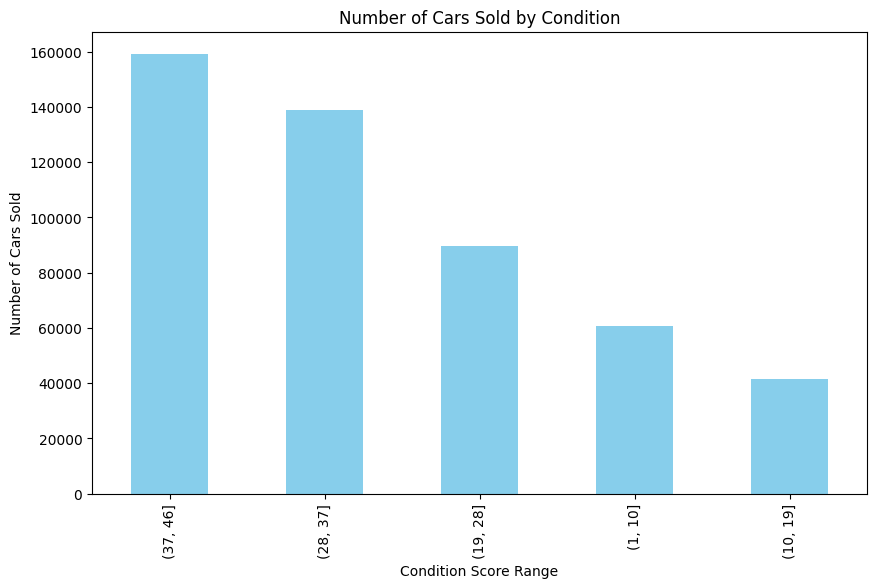

In [34]:
#3.6 Plot a bar graph of no. of cars sold by condition ranges of size 10. Give some insights from the graph.
import matplotlib.pyplot as plt
import pandas as pd
cars_sold_by_condition = df_cleaned.groupby(pd.cut(df_cleaned['condition'],\
                                                   bins=list(range(1,49,9))))
cars_sold_by_condition = cars_sold_by_condition['condition'].count()
cars_sold_by_condition=cars_sold_by_condition.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
cars_sold_by_condition.plot(kind='bar',color='skyblue')
plt.title('Number of Cars Sold by Condition')
plt.xlabel('Condition Score Range')
plt.ylabel('Number of Cars Sold')
plt.show()

#Insights:
#Range of condition 37-46 having maximum number of cars sold which is 160000.
#within 10-19 condition lowest number of cars have been sold whis is arround 40000.

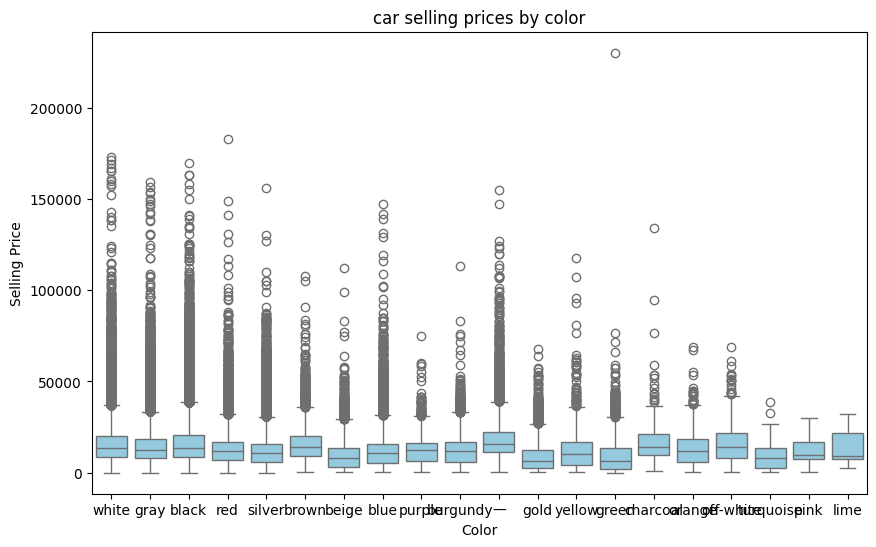

In [35]:
#3.7 Plot a box plot to show the distribution of car selling prices grouped by color.
#Extract insights and if required, remove outliers and plot the graph again.
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='color', y='sellingprice', data=df_cleaned, color='skyblue')
plt.title('car selling prices by color')
plt.xlabel('Color')
plt.ylabel('Selling Price')
plt.show()

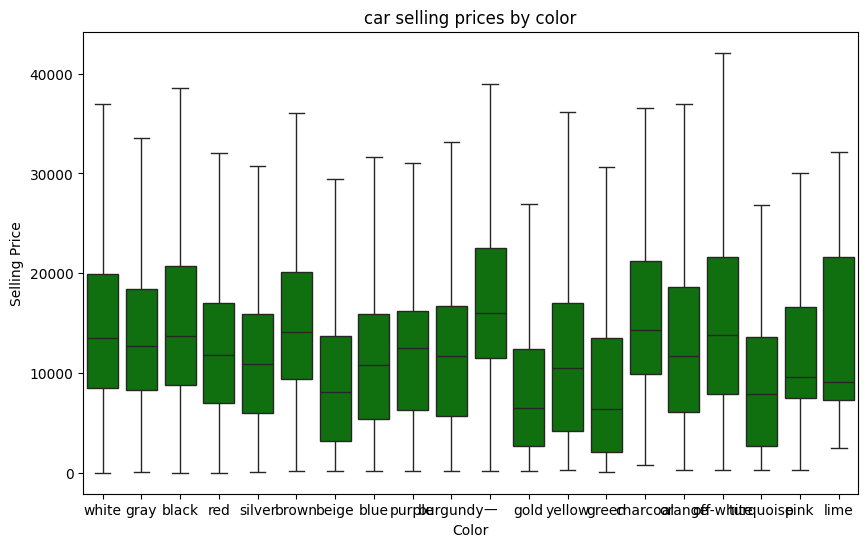

In [38]:
#remove outliers from box plot and plot the graph again
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='color', y='sellingprice',showfliers=0, data=df_cleaned, color='Green')
plt.title('car selling prices by color')
plt.xlabel('Color')
plt.ylabel('Selling Price')
plt.show()

